In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data
df = pd.read_csv("sales_data.csv")

# View first few rows
df.head()


,OrderID,Date,Product,Category,Quantity,Price,Customer,Region
0,1000,2023-01-01,Charger,Accessories,4,960,Customer_15,East
1,1001,2023-01-04,Tablet,Electronics,5,566,Customer_23,East
2,1002,2023-01-07,Tablet,Electronics,5,3271,Customer_40,West
3,1003,2023-01-10,Keyboard,Accessories,6,869,Customer_24,West
4,1004,2023-01-13,Phone,Electronics,2,1284,Customer_12,South


In [2]:
# Show number of rows and columns
df.shape


(120, 8)

In [3]:
df.columns


Index(['OrderID', 'Date', 'Product', 'Category', 'Quantity', 'Price',
       'Customer', 'Region'],
      dtype='object')

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   OrderID   120 non-null    int64 
 1   Date      120 non-null    object
 2   Product   120 non-null    object
 3   Category  120 non-null    object
 4   Quantity  120 non-null    int64 
 5   Price     120 non-null    int64 
 6   Customer  120 non-null    object
 7   Region    120 non-null    object
dtypes: int64(3), object(5)
memory usage: 7.6+ KB


In [5]:
df.isnull().sum()


OrderID     0
Date        0
Product     0
Category    0
Quantity    0
Price       0
Customer    0
Region      0
dtype: int64

In [6]:
df["Date"] = pd.to_datetime(df["Date"])


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   OrderID   120 non-null    int64         
 1   Date      120 non-null    datetime64[ns]
 2   Product   120 non-null    object        
 3   Category  120 non-null    object        
 4   Quantity  120 non-null    int64         
 5   Price     120 non-null    int64         
 6   Customer  120 non-null    object        
 7   Region    120 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 7.6+ KB


In [8]:
df["TotalSales"] = df["Quantity"] * df["Price"]


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OrderID     120 non-null    int64         
 1   Date        120 non-null    datetime64[ns]
 2   Product     120 non-null    object        
 3   Category    120 non-null    object        
 4   Quantity    120 non-null    int64         
 5   Price       120 non-null    int64         
 6   Customer    120 non-null    object        
 7   Region      120 non-null    object        
 8   TotalSales  120 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 8.6+ KB


In [10]:
df.head()

,OrderID,Date,Product,Category,Quantity,Price,Customer,Region,TotalSales
0,1000,2023-01-01,Charger,Accessories,4,960,Customer_15,East,3840
1,1001,2023-01-04,Tablet,Electronics,5,566,Customer_23,East,2830
2,1002,2023-01-07,Tablet,Electronics,5,3271,Customer_40,West,16355
3,1003,2023-01-10,Keyboard,Accessories,6,869,Customer_24,West,5214
4,1004,2023-01-13,Phone,Electronics,2,1284,Customer_12,South,2568


In [11]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month


In [12]:
df.head()

,OrderID,Date,Product,Category,Quantity,Price,Customer,Region,TotalSales,Year,Month
0,1000,2023-01-01,Charger,Accessories,4,960,Customer_15,East,3840,2023,1
1,1001,2023-01-04,Tablet,Electronics,5,566,Customer_23,East,2830,2023,1
2,1002,2023-01-07,Tablet,Electronics,5,3271,Customer_40,West,16355,2023,1
3,1003,2023-01-10,Keyboard,Accessories,6,869,Customer_24,West,5214,2023,1
4,1004,2023-01-13,Phone,Electronics,2,1284,Customer_12,South,2568,2023,1


In [13]:
top_products = (
    df.groupby("Product")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

top_products


Product
Speaker       204727
Monitor       200075
Mouse         169672
Laptop        157357
Headphones    152783
Name: TotalSales, dtype: int64

In [14]:
df.describe()


,OrderID,Quantity,Price,TotalSales,Year,Month
count,120.000000,120.000000,120.000000,120.000000,120.0,120.000000
mean,1059.500000,5.025000,2562.416667,12350.850000,2023.0,6.491667
std,34.785054,2.545263,1404.646584,9709.024436,0.0,3.478616
min,1000.000000,1.000000,198.000000,522.000000,2023.0,1.000000
25%,1029.750000,3.000000,1279.500000,3998.250000,2023.0,3.750000
50%,1059.500000,5.000000,2744.000000,9614.500000,2023.0,6.500000
75%,1089.250000,7.000000,3665.000000,16297.250000,2023.0,9.250000
max,1119.000000,9.000000,4993.000000,39969.000000,2023.0,12.000000


In [15]:
df["Category"].value_counts()


Electronics    54
Accessories    39
Audio          27
Name: Category, dtype: int64

In [16]:
df["Product"].value_counts()


Mouse         15
Laptop        14
Speaker       14
Keyboard      13
Headphones    13
Monitor       12
Charger       11
Phone         10
Smartwatch    10
Tablet         8
Name: Product, dtype: int64

In [17]:
df["Region"].value_counts()


West     47
East     27
North    24
South    22
Name: Region, dtype: int64

In [18]:
monthly_sales = (
    df.groupby(["Year", "Month"])["TotalSales"]
      .sum()
      .reset_index()
      .sort_values(["Year", "Month"])
)

monthly_sales


,Year,Month,TotalSales
0,2023,1,145945
1,2023,2,106660
2,2023,3,148628
3,2023,4,142207
4,2023,5,161765
5,2023,6,106756
6,2023,7,91728
7,2023,8,138324
8,2023,9,90548
9,2023,10,107045


In [19]:
category_sales = (
    df.groupby("Category")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales


Category
Electronics    698122
Accessories    426470
Audio          357510
Name: TotalSales, dtype: int64

In [20]:
region_sales = (
    df.groupby("Region")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales


Region
West     528196
East     352895
South    313144
North    287867
Name: TotalSales, dtype: int64

In [21]:
product_sales = (
    df.groupby("Product")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
)

product_sales


Product
Speaker       204727
Monitor       200075
Mouse         169672
Laptop        157357
Headphones    152783
Charger       145334
Smartwatch    137256
Phone         127405
Keyboard      111464
Tablet         76029
Name: TotalSales, dtype: int64

In [22]:
top5_products = product_sales.head(5)
top5_products


Product
Speaker       204727
Monitor       200075
Mouse         169672
Laptop        157357
Headphones    152783
Name: TotalSales, dtype: int64

In [23]:
bottom5_products = product_sales.tail(5)
bottom5_products


Product
Charger       145334
Smartwatch    137256
Phone         127405
Keyboard      111464
Tablet         76029
Name: TotalSales, dtype: int64

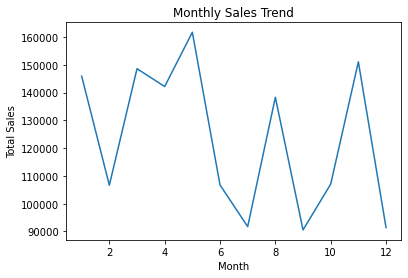

In [24]:
plt.plot(monthly_sales["Month"], monthly_sales["TotalSales"])
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.show()


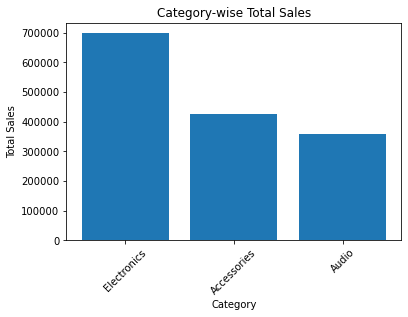

In [25]:
plt.bar(category_sales.index, category_sales.values)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Category-wise Total Sales")
plt.xticks(rotation=45)
plt.show()


In [26]:
SELECT 
    ProductName,
    SUM(SalesAmount) AS TotalSales
FROM sales
GROUP BY ProductName
ORDER BY TotalSales DESC;


IndentationError: unexpected indent (<ipython-input-26-9b74bce050f5>, line 2)

In [27]:
top_products = (
    df.groupby("Product")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
)

top_products


Product
Speaker       204727
Monitor       200075
Mouse         169672
Laptop        157357
Headphones    152783
Charger       145334
Smartwatch    137256
Phone         127405
Keyboard      111464
Tablet         76029
Name: TotalSales, dtype: int64

In [28]:
top_customers = (
    df.groupby("Customer")["TotalSales"]
      .sum()
      .nlargest(5)
)

top_customers


Customer
Customer_42    94612
Customer_39    92337
Customer_48    83107
Customer_33    81275
Customer_19    71538
Name: TotalSales, dtype: int64

In [29]:
best_region_per_category = (
    df.groupby(["Category", "Region"])["TotalSales"]
      .sum()
      .groupby("Category")
      .idxmax()
)

best_region_per_category


Category
Accessories    (Accessories, West)
Audio                (Audio, West)
Electronics    (Electronics, East)
Name: TotalSales, dtype: object

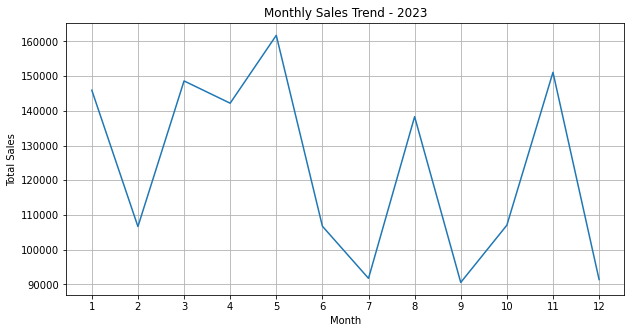

In [34]:
import matplotlib.pyplot as plt

# Monthly Sales Trend
plt.figure(figsize=(10, 5))  # Sets width and height of chart

plt.plot(monthly_sales["Month"], monthly_sales["TotalSales"])

plt.title("Monthly Sales Trend - 2023")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(monthly_sales["Month"])  # Show all 12 months on x-axis

plt.grid(True)  # Adds light grid lines to see trend better

plt.savefig("monthly_sales_trend.png")
plt.show()


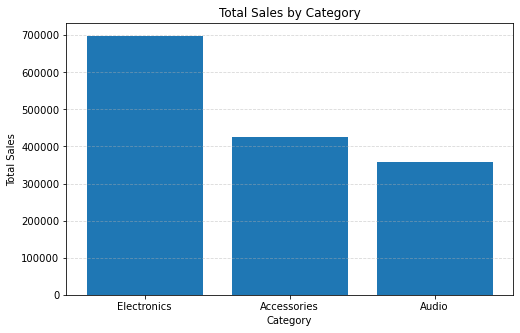

In [35]:
# Category-wise Sales (Bar Chart)
plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.grid(axis='y', linestyle='--', alpha=0.5)  # light grid on y-axis

plt.savefig("category_sales.png")

plt.show()


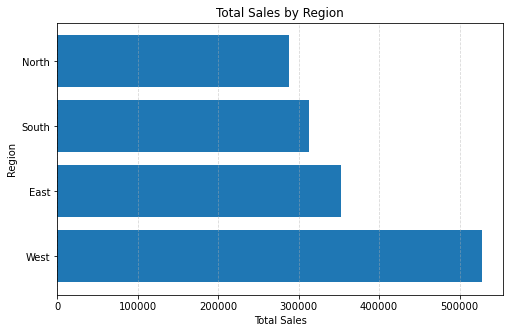

In [36]:
# Region-wise Sales (Horizontal Bar Chart)
plt.figure(figsize=(8, 5))

plt.barh(region_sales.index, region_sales.values)

plt.title("Total Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.savefig("region_sales.png")
plt.show()


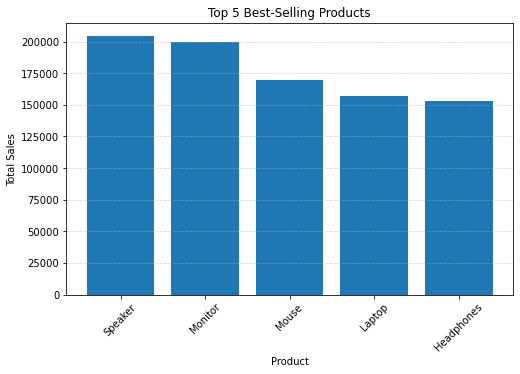

In [37]:
# Top 5 Best-Selling Products
top5_products = top_products.head(5)

plt.figure(figsize=(8, 5))
plt.bar(top5_products.index, top5_products.values)

plt.title("Top 5 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)  # tilt names slightly so they don’t overlap

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig("top5_products.png")
plt.show()
